In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    'User': ['A', 'A', 'A', 'B', 'B', 'C', 'C', 'D'],
    'Item': ['Item1', 'Item2', 'Item3', 'Item1', 'Item3', 'Item2', 'Item3', 'Item1'],
    'Rating': [5, 3, 4, 4, 2, 4, 5, 3]
}

df = pd.DataFrame(data)

print(df)

  User   Item  Rating
0    A  Item1       5
1    A  Item2       3
2    A  Item3       4
3    B  Item1       4
4    B  Item3       2
5    C  Item2       4
6    C  Item3       5
7    D  Item1       3


In [3]:
user_item_matrix = df.pivot_table(index='User', columns='Item', values='Rating')

print("\nUser-Item Matrix:\n")
print(user_item_matrix)


User-Item Matrix:

Item  Item1  Item2  Item3
User                     
A       5.0    3.0    4.0
B       4.0    NaN    2.0
C       NaN    4.0    5.0
D       3.0    NaN    NaN


In [4]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_item_matrix_filled)

similarity_df = pd.DataFrame(
    similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print("\nUser Similarity Matrix:\n")
print(similarity_df)


User Similarity Matrix:

User         A         B         C         D
User                                        
A     1.000000  0.885438  0.706762  0.707107
B     0.885438  1.000000  0.349215  0.894427
C     0.706762  0.349215  1.000000  0.000000
D     0.707107  0.894427  0.000000  1.000000


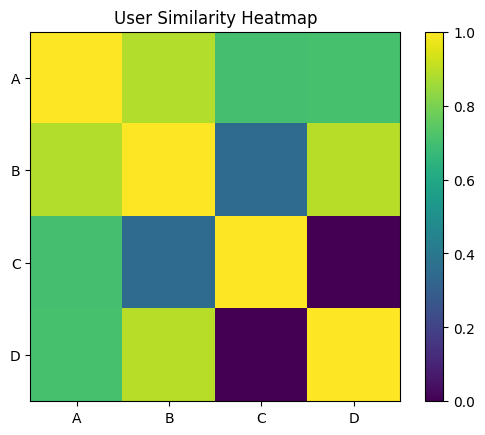

In [6]:
plt.figure()
plt.imshow(similarity)
plt.colorbar()
plt.title("User Similarity Heatmap")

plt.xticks(range(len(similarity_df)), similarity_df.columns)
plt.yticks(range(len(similarity_df)), similarity_df.index)

plt.show()

In [7]:
def recommend(user):
    similar_users = similarity_df[user].sort_values(ascending=False)[1:]
    
    print(f"\nTop similar users for {user}:\n", similar_users)
    
recommend('A')


Top similar users for A:
 User
B    0.885438
D    0.707107
C    0.706762
Name: A, dtype: float64


In [8]:
items = {
    'Item': ['Item1', 'Item2', 'Item3'],
    'Feature1': [1, 0, 1],
    'Feature2': [0, 1, 1]
}

item_df = pd.DataFrame(items)

print(item_df)

    Item  Feature1  Feature2
0  Item1         1         0
1  Item2         0         1
2  Item3         1         1


In [9]:
item_features = item_df.set_index('Item')

item_similarity = cosine_similarity(item_features)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_features.index,
    columns=item_features.index
)

print("\nItem Similarity Matrix:\n")
print(item_similarity_df)


Item Similarity Matrix:

Item      Item1     Item2     Item3
Item                               
Item1  1.000000  0.000000  0.707107
Item2  0.000000  1.000000  0.707107
Item3  0.707107  0.707107  1.000000


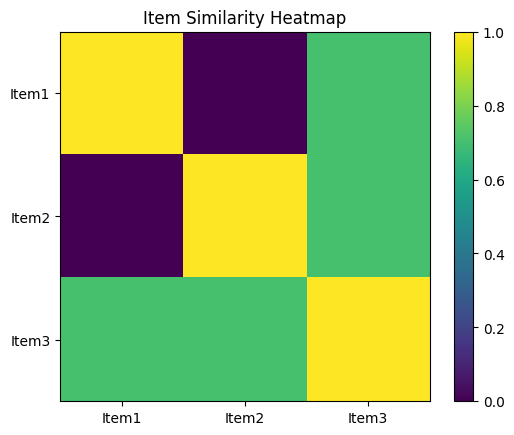

In [10]:
plt.figure()
plt.imshow(item_similarity)
plt.colorbar()
plt.title("Item Similarity Heatmap")

plt.xticks(range(len(item_similarity_df)), item_similarity_df.columns)
plt.yticks(range(len(item_similarity_df)), item_similarity_df.index)

plt.show()

In [11]:
def recommend_items(item):
    similar = item_similarity_df[item].sort_values(ascending=False)[1:]
    
    print(f"\nItems similar to {item}:\n", similar)

recommend_items('Item1')


Items similar to Item1:
 Item
Item3    0.707107
Item2    0.000000
Name: Item1, dtype: float64


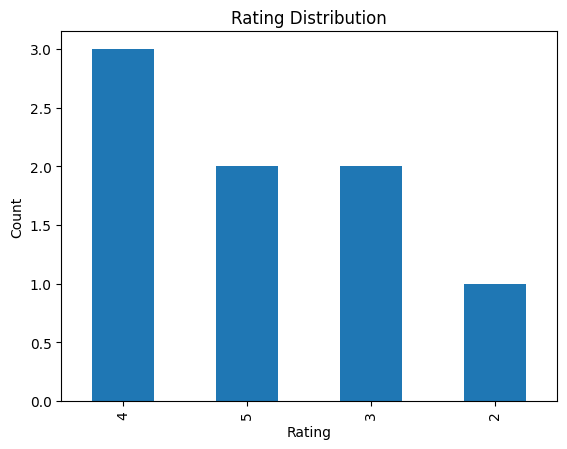

In [12]:
plt.figure()
df['Rating'].value_counts().plot(kind='bar')

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()